In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# Parameters
kqm = 110
kkm = 300
mu = 20
a = 3.477
mu_data = np.array([20,25,30,35,40,45,50,55,60,65,70,75,80])
xmaxdata = []
for j in range(len(mu_data)):
    # Import data
    data_file = f"wte2_susceptibility_{mu_data[j]}.dat"
    data1 = np.loadtxt(data_file)
    
    # Extract qx, qy, and the density values
    qx = data1[:, 0]
    qy = data1[:, 1]
    density = data1[:, 2]
    
    # Create a grid for plotting
    qx_unique = np.unique(qx)
    qy_unique = np.unique(qy)
    qx_grid, qy_grid = np.meshgrid(qx_unique, qy_unique)
    density_grid = interpolate.griddata((qx, qy), density, (qx_grid, qy_grid), method='linear')
    
    plt.rcParams["font.family"] = "serif"
    # plt.rcParams["font.serif"] = ["Times New Roman"]
    plt.rcParams["mathtext.fontset"] = "dejavuserif"  # or "stix"
    
    # Plot the data
    plt.figure(figsize=(10, 6))
    im = plt.imshow(density_grid, interpolation='bilinear',extent=(qx.min(), qx.max(), qy.min(), qy.max()), origin='lower', cmap='plasma')
    cbar =plt.colorbar(im,shrink=1.0,  location = 'top')
    cbar.ax.tick_params(labelsize=30)
    plt.xlabel(r'$q_x$ (1/Å)', fontsize=35)
    plt.ylabel(r'$q_y$ (1/Å)', fontsize=35)
    # plt.title(f'Susceptibility (μ = {mu})', fontsize=20)
    plt.gca().set_aspect('auto')
    plt.xticks([-0.5,0,0.5],fontsize=35)
    plt.yticks(fontsize=35)
    plt.tick_params(direction='out', length=5, width=1, colors='k', bottom=True, top=False, left=True, right=False)
    
    # Save the plot as PNG
    output_file_png = f"sus_2d_mu{mu_data[j]}.png"
    plt.savefig(output_file_png, dpi=300)
    output_file_pdf = f"sus_2d_mu{mu_data[j]}.pdf"
    plt.savefig(output_file_pdf, dpi=300)
    plt.show()
    
    # print(f"Plot saved as {output_file}")
    
    
    # Filter data where qy = 0
    qy_zero_mask = (qy == 0)
    qx_qy_zero = qx[qy_zero_mask]
    density_qy_zero = density[qy_zero_mask]
    
    # Calculate the maximum value of density and the corresponding qx value
    max_density = np.max(density_qy_zero)
    max_density_qx = qx_qy_zero[density_qy_zero == max_density]
    
    print(f"Maximum density value along qy=0: {max_density}")
    print(f"Corresponding qx values: {max_density_qx}")
    
    
    # Optional: You can also plot this information
    
    
    plt.rcParams["font.family"] = "serif"
    # plt.rcParams["font.serif"] = ["Times New Roman"]
    plt.rcParams["mathtext.fontset"] = "dejavuserif"  # or "stix"
    
    plt.figure(figsize=(10, 6))
    plt.plot(qx_qy_zero, density_qy_zero, color = 'k', lw = 2)
    # plt.scatter(max_density_qx, [max_density] * len(max_density_qx), color='red', label='Maximum Density')
    plt.xlabel(r'$q_x$ (1/Å)', fontsize=35 )
    plt.ylabel('$\chi$', fontsize=35)
    plt.tick_params(direction='in', length=5, width=1, colors='k', bottom=True, top=True, left=True, right=True)
    plt.text(0.42, max_density-0.2 ,f'$\mu$ = {mu_data[j]} meV' , fontsize=20)
    plt.text(0.42, max_density-0.6 ,f'q$_c$ = {max_density_qx[0]:.3f} 1/Å ' , fontsize=20)
    # plt.text(0.42, max_density-0.8 ,f'q$_y$ = 0.0 1/Å ' , fontsize=20)
    plt.xticks([-0.5,0,0.5],fontsize = 35)
    plt.yticks(fontsize = 35)
    plt.axvline(x = 0, color = 'k', ls = '-')
    plt.axvline(x = max_density_qx, color = 'magenta', ls = '--')
    plt.axvline(x = -max_density_qx, color = 'magenta', ls = '--')
    # Save the plot as PNG
    output_file_png = f"density_qy0_mu{mu_data[j]}.png"
    plt.savefig(output_file_png, dpi=300)
    output_file_pdf = f"density_qy0_mu{mu_data[j]}.pdf"
    plt.savefig(output_file_pdf, dpi=300)
    plt.show()
    
    xmaxdata.append([mu_data[j], max_density, abs(max_density_qx[0])])
    
xmaxdata = np.array(xmaxdata)
np.savetxt("xmaxdata.dat", xmaxdata)

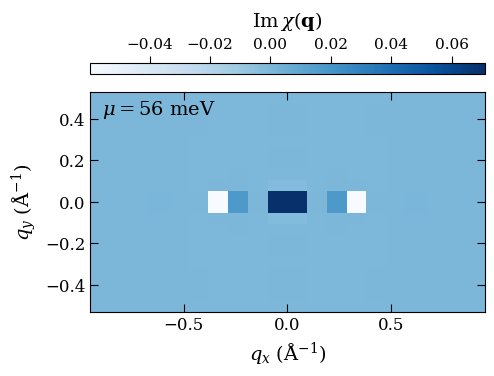

In [15]:

from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.pyplot as plt
import numpy as np


# =============================================================================
# Files and plot choices
# =============================================================================

mu = 0.056
num_k = 50
num_q = 19

INPUT_FILE = Path(f"wte2_sus_multi_core_mu_{mu*1000}_k_{num_k}_q_{num_q}.dat")
OUTPUT_BASENAME = Path(f"lindhard_imaginary_qx_qy_mu_{mu*1000}_k_{num_k}_q_{num_q}")

COLORMAP = "Blues"


# =============================================================================
# Publication-style settings
# =============================================================================

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "mathtext.fontset": "dejavuserif",
        "font.size": 12,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "savefig.dpi": 300,
    }
)


def load_susceptibility_grid(filename):
    """Load the four-column data and reconstruct the rectangular q grid."""

    data = np.loadtxt(filename, comments="#")

    # np.loadtxt returns a 1D array if the file contains only one row.
    if data.ndim == 1:
        data = data[np.newaxis, :]

    if data.shape[1] < 4:
        raise ValueError(
            f"{filename} contains {data.shape[1]} columns; at least four "
            "columns are required: qx, qy, Re[chi], Im[chi]."
        )

    qx = data[:, 0]
    qy = data[:, 1]
    chi_imaginary = data[:, 3]

    qx_unique, qx_index = np.unique(qx, return_inverse=True)
    qy_unique, qy_index = np.unique(qy, return_inverse=True)

    expected_points = qx_unique.size * qy_unique.size
    unique_pairs = np.unique(np.column_stack((qx, qy)), axis=0).shape[0]

    if data.shape[0] != expected_points or unique_pairs != expected_points:
        raise ValueError(
            "The input points do not form one complete rectangular qx-qy grid."
        )

    # The first index labels qx and the second labels qy:
    # chi_grid[ix, iy] = Im[chi(qx[ix], qy[iy])].
    chi_grid = np.empty((qx_unique.size, qy_unique.size), dtype=np.float64)
    chi_grid[qx_index, qy_index] = chi_imaginary

    return qx_unique, qy_unique, chi_grid



qx, qy, chi_imaginary = load_susceptibility_grid(INPUT_FILE)

fig, ax = plt.subplots(figsize=(5, 4))

mesh = ax.pcolormesh(
    qx,
    qy,
    chi_imaginary.T,
    shading="auto",
    cmap=COLORMAP,
    rasterized=True,
)

cax = inset_axes(
    ax,
    width="100%",       # same width as the plot
    height="5%",
    loc="lower left",
    bbox_to_anchor=(0, 1.08, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

colorbar = fig.colorbar(
    mesh,
    cax=cax,
    orientation="horizontal",
)

colorbar.set_label(
    r"$\mathrm{Im}\,\chi(\mathbf{q})$",
    fontsize=14,
    labelpad=8,
)

colorbar.ax.xaxis.set_ticks_position("top")
colorbar.ax.xaxis.set_label_position("top")
colorbar.ax.tick_params(
    direction="out",
    length=5,
    width=0.8,
    labelsize=11,
)

colorbar.outline.set_linewidth(0.8)

ax.set_xlabel(r"$q_x$ ($\mathrm{\AA}^{-1}$)")
ax.set_ylabel(r"$q_y$ ($\mathrm{\AA}^{-1}$)")
ax.set_aspect("equal", adjustable="box")
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.text(
    0.03,
    0.97,
    rf"$\mu = {mu * 1000:g}\ \mathrm{{meV}}$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=14,
    color="black",
)

fig.subplots_adjust(left=0.16, right=0.95, bottom=0.14, top=0.82)
fig.savefig(
    OUTPUT_BASENAME.with_suffix(".pdf"),
    bbox_inches="tight",
)
fig.savefig(
    OUTPUT_BASENAME.with_suffix(".png"),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

